# Sample Superstore: Retail Sales & Profitability Analysis

## Introduction

### Project Objective
The objective of this project is to perform a comprehensive data analytics workflow—encompassing data acquisition, initial data exploration, data cleaning, calculation of Key Performance Indicators (KPIs), and Exploratory Data Analysis (EDA)—on the Sample Superstore dataset. The analysis aims to uncover operational trends, identify high- and low-performing product categories and geographic regions, evaluate the impact of discount strategies on profit margins, and deliver actionable business insights to drive revenue growth and profitability.

### Dataset Overview
The dataset contains transactional data for a US-based nationwide retail store (Superstore) spanning from January 2018 through December 2021. It comprises 9,994 records across 21 feature columns, detailing order information, shipping logistics, customer demographics, geographic locations, product categories, sales, order quantities, applied discounts, and net profits.

### Tools & Libraries Used
- **Pandas**: Data manipulation, aggregation, time-series conversion, and tabular analysis.
- **NumPy**: Numerical operations and vector calculations.
- **Matplotlib**: Static visualizations, bar charts, line plots, heatmaps, and scatter plots.
- **Kagglehub & Pathlib**: Automated dataset acquisition and local directory path management.

### Scope of Analysis
1. Environment Setup & Data Acquisition
2. Initial Data Quality Assessment & Exploration
3. Data Cleaning, Type Conversion & Data Export
4. Key Performance Indicator (KPI) Calculation
5. Categorical, Regional, Temporal, and Customer Segment EDA
6. Correlation & Discount Impact Analysis
7. Key Business Insights & Strategic Recommendations


## 1. Import Libraries

**Purpose**: Load core Python libraries required for data manipulation, numerical computing, and visualization, and configure global display settings.
**Why**: Setting `display.max_columns` to `None` ensures all 21 columns of the Superstore dataset remain fully visible during tabular display without truncation.
**Expected Insights**: A clean environment with Pandas, NumPy, and Matplotlib imported.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns
pd.set_option("display.max_columns", None)

## 2. Dataset Acquisition

**Purpose**: Programmatically download the Tableau Sample Superstore dataset using the `kagglehub` API and save the raw CSV file to the project data directory (`../../data/raw/superstore.csv`).
**Why**: Automates data retrieval and establishes a standardized local raw data path.
**Reproducibility Note**: The dataset was downloaded once via KaggleHub and saved locally. All subsequent analysis in this notebook loads from this local CSV file for complete reproducibility and efficient processing.
**Expected Insights**: Confirmation of dataset download and file transfer to the target directory.


In [1]:
import kagglehub
import shutil
from pathlib import Path

# Download dataset
dataset_path = Path(kagglehub.dataset_download("truongdai/tableau-sample-superstore"))

print("Downloaded to:", dataset_path)

# Find the dataset file
source_file = next(dataset_path.glob("*"))

# Destination in your project
destination = Path("../../data/raw") / source_file.name

# Copy it
shutil.copy(source_file, destination)

print(f"Dataset copied to: {destination}")

100%|██████████| 994k/994k [00:00<00:00, 1.31MB/s]

Extracting files...
Downloaded to: /Users/shubham/.cache/kagglehub/datasets/truongdai/tableau-sample-superstore/versions/1
Dataset copied to: ../../data/raw/Sample - Superstore.xls


## 3. Load Dataset

**Purpose**: Read the raw CSV file into a Pandas DataFrame and inspect the first few rows using `.head()`.
**Why**: Verifies successful data ingestion and provides an initial preview of column names, data formatting, and sample record values.
**Expected Insights**: Overview of sample transactional records including Order ID, Customer Name, Region, Category, Sales, and Profit.


In [18]:
df = pd.read_csv("../../data/raw/superstore.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2020-152156,2020-11-08,2020-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2020-152156,2020-11-08,2020-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2020-138688,2020-06-12,2020-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2019-108966,2019-10-11,2019-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2019-108966,2019-10-11,2019-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 4. Initial Data Exploration

### 4.1 Dataset Structure and Data Types

**Purpose**: Inspect total rows, columns, memory footprint, and column dtypes using `.shape` and `.info()`.
**Why**: Identifies dataset scale (9,994 rows, 21 columns) and highlights non-null counts and potential data type mismatches (e.g., date columns stored as strings).
**Expected Insights**: Understanding of dataset dimensions and column data types.


In [19]:
print("Shape:", df.shape)

df.info()

Shape: (9994, 21)
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          9994 non-null   int64  
 1   Order ID        9994 non-null   str    
 2   Order Date      9994 non-null   str    
 3   Ship Date       9994 non-null   str    
 4   Ship Mode       9994 non-null   str    
 5   Customer ID     9994 non-null   str    
 6   Customer Name   9994 non-null   str    
 7   Segment         9994 non-null   str    
 8   Country/Region  9994 non-null   str    
 9   City            9994 non-null   str    
 10  State           9994 non-null   str    
 11  Postal Code     9983 non-null   float64
 12  Region          9994 non-null   str    
 13  Product ID      9994 non-null   str    
 14  Category        9994 non-null   str    
 15  Sub-Category    9994 non-null   str    
 16  Product Name    9994 non-null   str    
 17  Sales           9994 non-n

*Interpretation*: The raw dataset contains 9,994 entries and 21 columns. All columns have 9,994 non-null entries except `Postal Code` which has 11 missing values (9,983 non-null). `Order Date` and `Ship Date` are stored as string objects and require conversion to datetime format.


### 4.2 Full Statistical Summary

**Purpose**: Compute descriptive statistics for all columns in the dataset using `df.describe(include="all")`.
**Why**: `describe(include="all")` provides a comprehensive overview summarizing all 21 feature columns—both categorical text fields and numerical attributes—showing unique counts, top categories, frequencies, ranges, means, and standard deviations.
**Expected Insights**: Initial visibility into feature ranges, primary categorical values, and overall data spread.


In [20]:
df.describe(include="all")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9983.000000,9994,9994,9994,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000
unique,NaN,5009,1236,1334,4,793,793,3,1,531,49,NaN,4,1862,3,17,1849,NaN,NaN,NaN,NaN
top,NaN,CA-2021-100111,2020-09-05,2019-12-16,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN,NaN,NaN,NaN
freq,NaN,14,38,35,5968,37,37,5191,9994,915,2001,NaN,3203,19,6026,1523,48,NaN,NaN,NaN,NaN
mean,4997.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55245.233297,NaN,NaN,NaN,NaN,NaN,229.858001,3.789574,0.156203,28.656896
std,2885.163629,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32038.715955,NaN,NaN,NaN,NaN,NaN,623.245101,2.225110,0.206452,234.260108
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23223.000000,NaN,NaN,NaN,NaN,NaN,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,57103.000000,NaN,NaN,NaN,NaN,NaN,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90008.000000,NaN,NaN,NaN,NaN,NaN,209.940000,5.000000,0.200000,29.364000


*Interpretation*: The dataset spans 5,009 unique orders across 793 customers in 49 US states. Consumer segment is the largest customer segment (5,191 orders). Standard Class is the predominant shipping mode (5,968 orders). Sales range from $0.44 to $22,638.48, while Profit ranges from -$6,599.98 to $8,399.98, indicating substantial variance and negative profit margins on certain transactions.


### 4.3 Missing Value Audit

**Purpose**: Count missing (null) values per column across the dataset.
**Why**: Data completeness is essential for accurate calculations and prevents unexpected errors during grouping or plotting.
**Expected Insights**: Identification of specific columns containing missing values.


In [21]:
df.isnull().sum()

Row ID             0
Order ID           0
Order Date         0
Ship Date          0
Ship Mode          0
Customer ID        0
Customer Name      0
Segment            0
Country/Region     0
City               0
State              0
Postal Code       11
Region             0
Product ID         0
Category           0
Sub-Category       0
Product Name       0
Sales              0
Quantity           0
Discount           0
Profit             0
dtype: int64

*Interpretation*: `Postal Code` is the only column containing missing values, with exactly 11 missing entries out of 9,994 total rows.


### 4.4 Duplicate Records Check

**Purpose**: Verify whether any identical duplicate rows exist in the DataFrame.
**Why**: Duplicate records distort aggregate totals such as Sales, Profit, and Order Count.
**Expected Insights**: Confirmation of record uniqueness.


In [22]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


*Interpretation*: Zero duplicate rows were found in the dataset, confirming that each row represents a distinct order line item.


### 4.5 Column Names Inspection

**Purpose**: Retrieve the full list of column names in the DataFrame using `.columns.tolist()`.
**Why**: Ensures exact column naming conventions are understood for downstream indexing and transformation.
**Expected Insights**: List of all 21 feature names.


In [23]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country/Region',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

### 4.6 Missing Values Verification

**Purpose**: Re-examine missing value counts across all features.
**Why**: Confirms missing value distribution prior to data cleaning operations.
**Expected Insights**: Re-confirmation of 11 missing values in `Postal Code`.


In [24]:
# Display missing values
df.isnull().sum()

Row ID             0
Order ID           0
Order Date         0
Ship Date          0
Ship Mode          0
Customer ID        0
Customer Name      0
Segment            0
Country/Region     0
City               0
State              0
Postal Code       11
Region             0
Product ID         0
Category           0
Sub-Category       0
Product Name       0
Sales              0
Quantity           0
Discount           0
Profit             0
dtype: int64

### 4.7 Column Data Types Check

**Purpose**: Inspect exact dtypes for all features using `.dtypes`.
**Why**: Identifies features requiring type casting (e.g., date strings to datetime objects).
**Expected Insights**: Detailed mapping of column data types.


In [25]:
# Display data types
df.dtypes

Row ID              int64
Order ID              str
Order Date            str
Ship Date             str
Ship Mode             str
Customer ID           str
Customer Name         str
Segment               str
Country/Region        str
City                  str
State                 str
Postal Code       float64
Region                str
Product ID            str
Category              str
Sub-Category          str
Product Name          str
Sales             float64
Quantity            int64
Discount          float64
Profit            float64
dtype: object

### 4.8 Categorical Cardinality Analysis

**Purpose**: Count unique values for each string/object column.
**Why**: Assesses cardinality across categorical dimensions such as Order ID, Customer ID, City, State, Category, and Sub-Category.
**Expected Insights**: Cardinality counts (e.g., 3 Categories, 17 Sub-Categories, 4 Regions, 3 Segments).


In [27]:
# Check unique values in categorical columns
categorical_cols = df.select_dtypes(include=["object", "string"])

for col in categorical_cols:
    print(f"\n{col}: {df[col].nunique()} unique values")


Order ID: 5009 unique values

Order Date: 1236 unique values

Ship Date: 1334 unique values

Ship Mode: 4 unique values

Customer ID: 793 unique values

Customer Name: 793 unique values

Segment: 3 unique values

Country/Region: 1 unique values

City: 531 unique values

State: 49 unique values

Region: 4 unique values

Product ID: 1862 unique values

Category: 3 unique values

Sub-Category: 17 unique values

Product Name: 1849 unique values


*Interpretation*: The dataset contains 3 main Categories, 17 Sub-Categories, 4 Regions, 3 Segments, and 4 Ship Modes, establishing the core dimensions for categorical EDA.


### 4.9 Numerical Distribution Summary

**Purpose**: Compute descriptive statistics specifically for numerical features using `df.describe()`.
**Why**: While `describe(include="all")` in Section 4.2 summarizes the entire dataset including text fields, standard `describe()` focuses exclusively on quantitative numerical variables (`Postal Code`, `Sales`, `Quantity`, `Discount`, `Profit`). This isolates key distribution metrics (mean, standard deviation, minimum, quartiles, and maximum) to evaluate numeric dispersion and central tendency.
**Expected Insights**: Summary metrics showing average order sales (~$229.86), average profit (~$28.66), and average discount rate (~15.6%).


In [28]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9983.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55245.233297,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32038.715955,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,57103.000000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


### 4.10 Categorical Frequency Counts

**Purpose**: Examine order frequency distributions across key categorical variables: Category, Segment, Region, and Ship Mode.
**Why**: Identifies main volume drivers in terms of transaction volume.
**Expected Insights**: Office Supplies dominates order volume (6,026 orders), followed by Consumer segment (5,191 orders) and West region (3,203 orders).


In [29]:
for col in ["Category", "Segment", "Region", "Ship Mode"]:
    print(f"\n{col}")
    print(df[col].value_counts())


Category
Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

Segment
Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64

Region
Region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64

Ship Mode
Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64


*Interpretation*: Office Supplies accounts for the highest order volume (6,026 transactions, ~60.3%), Consumer is the primary customer segment (5,191 transactions, ~51.9%), West is the top region by transaction count (3,203), and Standard Class is the preferred shipping method (5,968 transactions, ~59.7%).


### 4.11 Transaction Date Range Check

**Purpose**: Identify earliest and latest order dates in the dataset.
**Why**: Establishes the exact timeframe covered by the retail dataset.
**Expected Insights**: Timeframe span from January 3, 2018 to December 30, 2021.


In [30]:
print(df["Order Date"].min())
print(df["Order Date"].max())

2018-01-03
2021-12-30


*Interpretation*: The dataset spans exactly 4 full calendar years, from January 3, 2018 to December 30, 2021.


## 5. Data Cleaning

### 5.1 Date Format Conversion

**Purpose**: Convert `Order Date` and `Ship Date` columns from object strings to datetime objects using `pd.to_datetime()`.
**Why**: Datetime formatting enables time-series operations, monthly aggregations, and trend extraction.
**Expected Insights**: Datetime dtypes for both date columns.


In [31]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

### 5.2 Post-Conversion Data Types Inspection

**Purpose**: Verify updated DataFrame dtypes following date conversion.
**Why**: Confirms successful type transformation.
**Expected Insights**: `Order Date` and `Ship Date` confirmed as `datetime64[us]`.


In [32]:
df.dtypes

Row ID                     int64
Order ID                     str
Order Date        datetime64[us]
Ship Date         datetime64[us]
Ship Mode                    str
Customer ID                  str
Customer Name                str
Segment                      str
Country/Region               str
City                         str
State                        str
Postal Code              float64
Region                       str
Product ID                   str
Category                     str
Sub-Category                 str
Product Name                 str
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
dtype: object

### 5.3 Inspection of Rows with Missing Postal Code

**Purpose**: Display the specific 11 records containing missing `Postal Code` values.
**Why**: Evaluates whether missing postal codes impact critical fields or belong to a specific location.
**Expected Insights**: All 11 missing postal codes belong to orders placed in Burlington, Vermont.


In [33]:
df[df["Postal Code"].isnull()]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
2234,2235,CA-2021-104066,2021-12-05,2021-12-10,Standard Class,QJ-19255,Quincy Jones,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10001013,Technology,Accessories,Logitech ClearChat Comfort/USB Headset H390,205.03,7,0.0,67.6599
5274,5275,CA-2019-162887,2019-11-07,2019-11-09,Second Class,SV-20785,Stewart Visinsky,Consumer,United States,Burlington,Vermont,NaN,East,FUR-CH-10000595,Furniture,Chairs,Safco Contoured Stacking Chairs,715.20,3,0.0,178.8000
8798,8799,US-2020-150140,2020-04-06,2020-04-10,Standard Class,VM-21685,Valerie Mitchum,Home Office,United States,Burlington,Vermont,NaN,East,TEC-PH-10002555,Technology,Phones,Nortel Meridian M5316 Digital phone,1294.75,5,0.0,336.6350
9146,9147,US-2020-165505,2020-01-23,2020-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10002926,Technology,Accessories,Logitech Wireless Marathon Mouse M705,99.98,2,0.0,42.9914
9147,9148,US-2020-165505,2020-01-23,2020-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-AR-10003477,Office Supplies,Art,4009 Highlighters,8.04,6,0.0,2.7336
9148,9149,US-2020-165505,2020-01-23,2020-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-ST-10001526,Office Supplies,Storage,Iceberg Mobile Mega Data/Printer Cart,1564.29,13,0.0,406.7154
9386,9387,US-2021-127292,2021-01-19,2021-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10000157,Office Supplies,Paper,Xerox 191,79.92,4,0.0,37.5624
9387,9388,US-2021-127292,2021-01-19,2021-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10001970,Office Supplies,Paper,Xerox 1881,12.28,1,0.0,5.7716
9388,9389,US-2021-127292,2021-01-19,2021-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-AP-10000828,Office Supplies,Appliances,Avanti 4.4 Cu. Ft. Refrigerator,542.94,3,0.0,152.0232
9389,9390,US-2021-127292,2021-01-19,2021-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-EN-10001509,Office Supplies,Envelopes,Poly String Tie Envelopes,2.04,1,0.0,0.9588


*Interpretation*: All 11 missing `Postal Code` entries correspond to transactions in Burlington, Vermont. Because this represents a negligible fraction of records (~0.11%), removing these rows maintains dataset integrity without biasing overall analysis.


### 5.4 Outlier Analysis via Box Plots

**Purpose**: Visualize distributions of `Sales`, `Profit`, `Quantity`, and `Discount` using box plots.
**Why**: Box plots reveal potential outliers, skewness, and extreme values across numerical metrics.
**Expected Insights**: Significant high-side outliers in Sales and Profit, reflecting high-value commercial transactions and steep losses on heavy discounts.


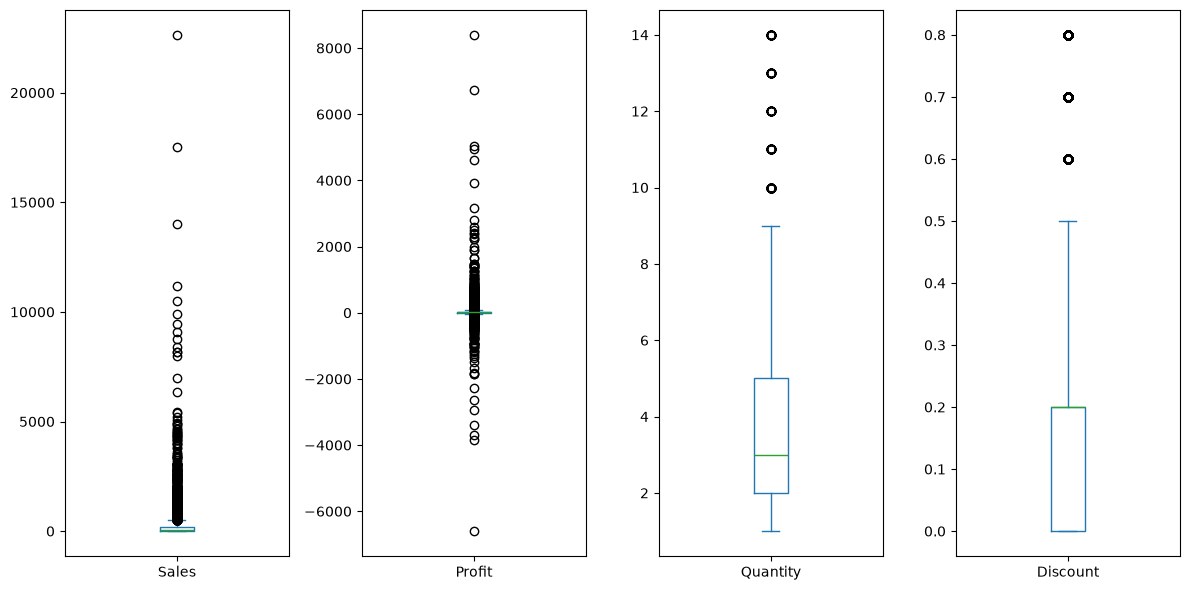

In [34]:
numerical_cols = ["Sales", "Profit", "Quantity", "Discount"]

df[numerical_cols].plot(
    kind="box",
    subplots=True,
    figsize=(12, 6)
)

plt.tight_layout()
plt.show()

*Interpretation*: Box plots reveal substantial right-skewness and extreme upper-bound values in both Sales (up to $22,638.48) and Profit (up to $8,399.98), alongside negative profit values (down to -$6,599.98). Crucially, these detected outliers represent legitimate high-value commercial transactions and heavy discount losses rather than data entry errors. As a result, all outliers are intentionally retained in the dataset to preserve authentic business performance metrics.


### 5.5 Missing Data Removal

**Purpose**: Remove rows where `Postal Code` is missing using `dropna()`.
**Why**: Cleanses the dataset of incomplete location data to prepare a final curated dataset for EDA and reporting.
**Expected Insights**: Reduction of row count from 9,994 to 9,983 rows.


In [36]:
# Remove rows with missing Postal Code
df = df.dropna(subset=["Postal Code"])

### 5.6 Post-Cleaning Verification

**Purpose**: Confirm zero remaining null values and check final cleaned DataFrame shape.
**Why**: Validates that all missing values have been resolved cleanly.
**Expected Insights**: Zero missing values and a final cleaned dataset shape of (9,983, 21).


In [37]:
print("Remaining Missing Values")
print(df.isnull().sum())

print("\nDataset Shape")
print(df.shape)

Remaining Missing Values
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State             0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

Dataset Shape
(9983, 21)


*Interpretation*: Data cleaning is complete. All 21 features now contain zero missing values across 9,983 valid records.


### 5.7 Export Cleaned Dataset

**Purpose**: Save processed DataFrame as a CSV file to `../../data/cleaned/superstore_cleaned.csv`.
**Why**: Exports a reliable, cleaned data artifact for downstream modeling, dashboarding, or portfolio sharing.
**Expected Insights**: Confirmation message that the cleaned dataset was saved successfully.


In [38]:
df.to_csv("../../data/cleaned/superstore_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


## 6. Key Performance Indicators (KPIs)

**Purpose**: Calculate top-level business health metrics including Total Sales, Total Profit, Total Orders, and Total Unique Customers.
**Why**: Provides an immediate executive summary of business scale and overall financial performance over the 4-year period.
**Expected Insights**: High-level financial KPIs for executive overview.


In [39]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders}")
print(f"Total Customers: {total_customers}")

Total Sales: $2,288,271.49
Total Profit: $284,152.04
Total Orders: 5003
Total Customers: 793


*Key Performance Indicators (KPI Summary)*:
Over the 4-year analysis period (2018–2021), the Superstore achieved the following overall business metrics:

- **Total Sales**: **$2,288,271.49**
- **Total Net Profit**: **$284,152.04**
- **Overall Profit Margin**: **12.42%**
- **Total Orders**: **5,003** unique orders
- **Total Customers**: **793** unique customers


## 7. Exploratory Data Analysis (EDA)

### 7.1 Product Category Performance: Sales & Profit Analysis

**Purpose**: Aggregate and compare total Sales and Profit across the three main product categories: Technology, Furniture, and Office Supplies.
**Why**: Evaluates category profitability and identifies margin disparities relative to sales volume.
**Expected Insights**: Technology leads in both revenue and profit, whereas Furniture generates substantial revenue but disproportionately low profit.


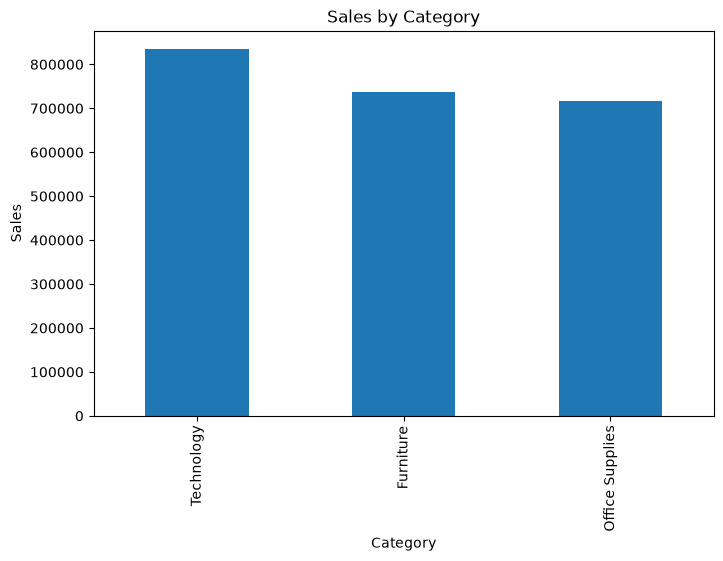

In [40]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

category_sales.plot(
    kind="bar",
    figsize=(8,5),
    title="Sales by Category"
)

plt.ylabel("Sales")
plt.show()

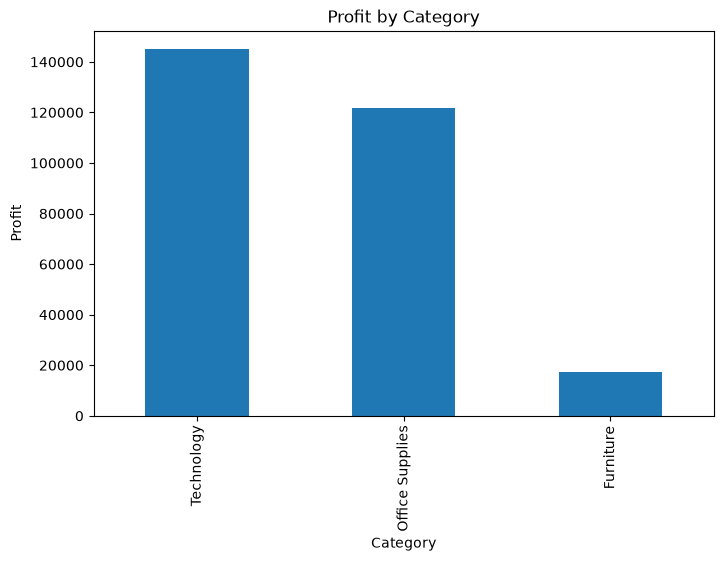

In [41]:
category_profit = (
    df.groupby("Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

category_profit.plot(
    kind="bar",
    figsize=(8,5),
    title="Profit by Category"
)

plt.ylabel("Profit")
plt.show()

*Interpretation*: 
- **Technology** is the top performer, generating the highest sales (**$834,554.27**) and net profit (**$145,007.66**).
- **Office Supplies** generated **$716,837.52** in sales and **$121,885.04** in profit, achieving a strong profit margin of **17.0%**.
- **Furniture** produced strong sales (**$736,879.70**) but a comparatively very low profit (**$17,259.35**), resulting in an alarming profit margin of only **2.34%**.


### 7.2 Regional Performance: Sales & Profit Analysis

**Purpose**: Measure total Sales and Profit breakdown across the four geographic regions (West, East, Central, South).
**Why**: Highlights geographic strengths and flags underperforming territories.
**Expected Insights**: West region leads all territories in both sales and profitability, while Central region underperforms in profit.


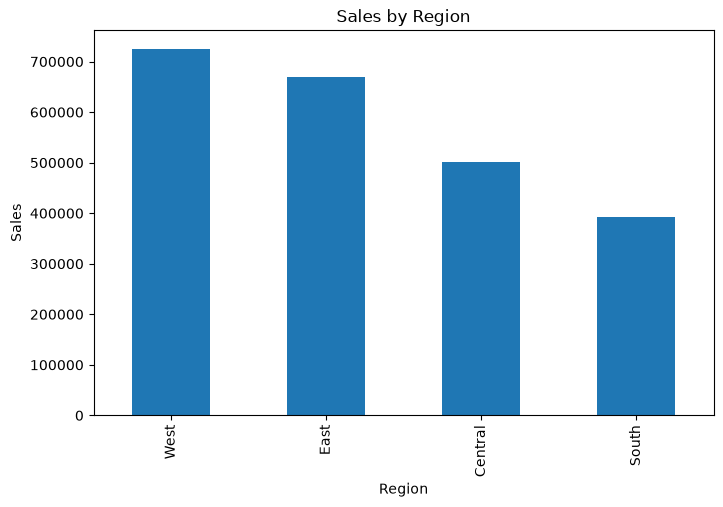

In [42]:
region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

region_sales.plot(
    kind="bar",
    figsize=(8,5),
    title="Sales by Region"
)

plt.ylabel("Sales")
plt.show()

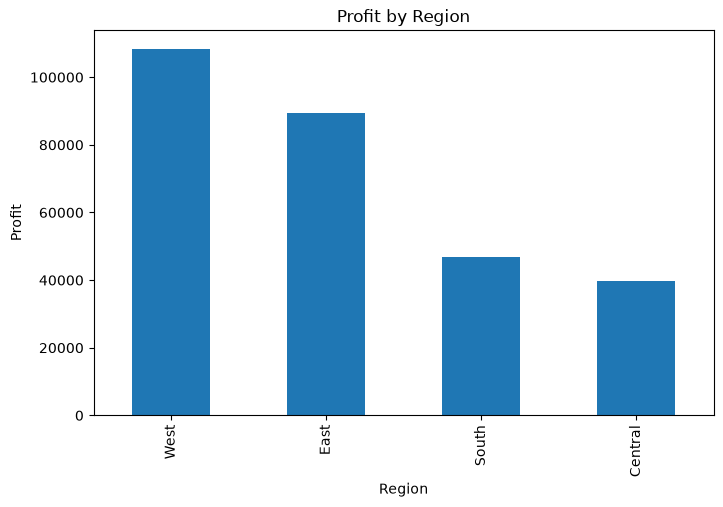

In [43]:
region_profit = (
    df.groupby("Region")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

region_profit.plot(
    kind="bar",
    figsize=(8,5),
    title="Profit by Region"
)

plt.ylabel("Profit")
plt.show()

*Interpretation*:
- **West** region performed best overall, leading in both total sales (**$725,457.82**) and total profit (**$108,418.45**).
- **East** region ranked second with **$669,851.87** in sales and **$89,277.80** in profit.
- **Central** region generated **$501,239.89** in sales but only **$39,706.36** in profit (7.92% margin), impacted by heavy discounting.
- **South** region recorded the lowest sales volume (**$391,721.91**) but maintained a healthy profit of **$46,749.43** (11.93% margin).


### 7.3 Time-Series Analysis: Monthly Sales & Profit Trends

**Purpose**: Construct a monthly time-series field (`YearMonth`) and plot monthly Sales and Profit trends from 2018 through 2021.
**Why**: Uncovers seasonal purchase patterns, annual growth trajectories, and period-over-period performance consistency.
**Expected Insights**: Strong upward trajectory over the 4-year period with consistent Q4 sales surges (November–December holiday peaks).


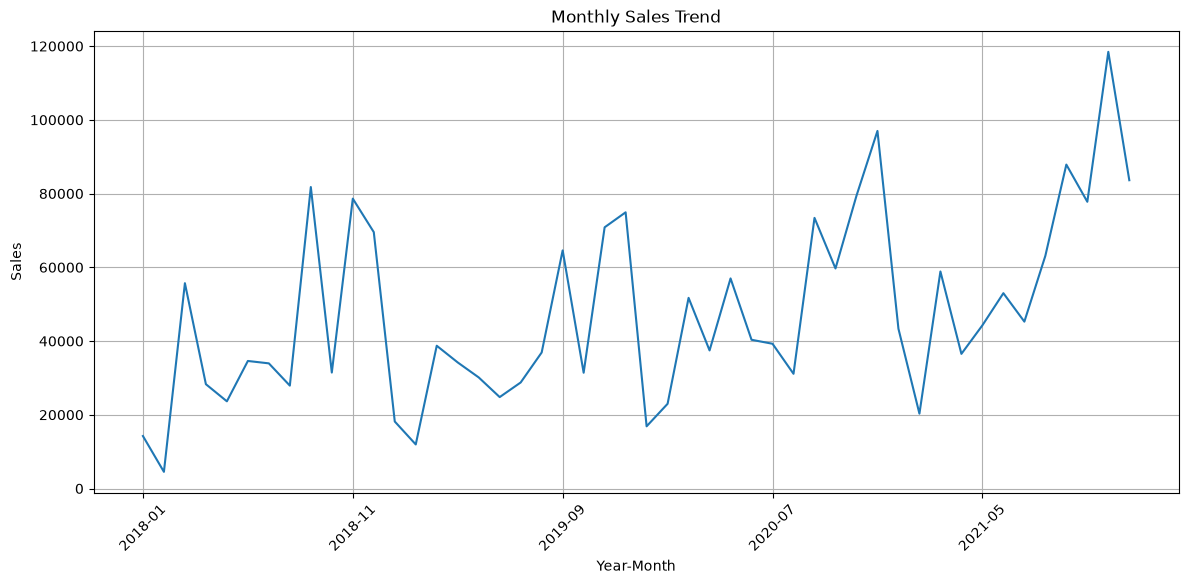

In [44]:
df["YearMonth"] = df["Order Date"].dt.to_period("M").astype(str)

monthly_sales = (
    df.groupby("YearMonth")["Sales"]
      .sum()
)

plt.figure(figsize=(14,6))
monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Year-Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

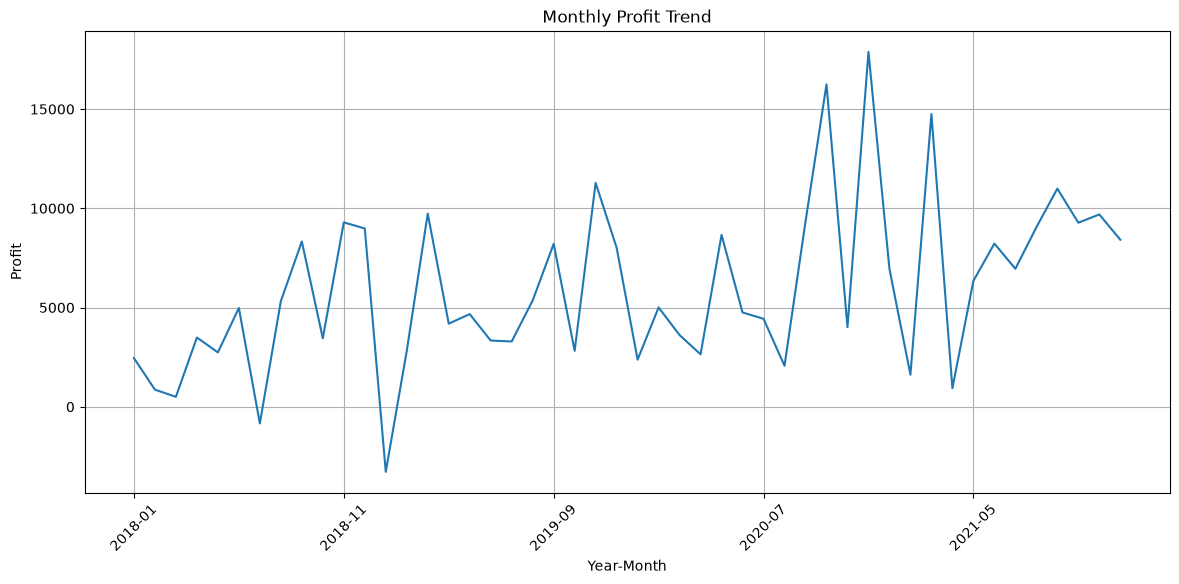

In [45]:
monthly_profit = (
    df.groupby("YearMonth")["Profit"]
      .sum()
)

plt.figure(figsize=(14,6))
monthly_profit.plot()

plt.title("Monthly Profit Trend")
plt.xlabel("Year-Month")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

*Interpretation*:
- **Sales Growth**: Monthly sales demonstrated a consistent upward trajectory from 2018 to 2021, featuring recurring end-of-year peaks every November and December due to holiday demand.
- **Profit Alignment**: Monthly profit closely mirrors monthly sales trends, though sharp dips into lower profitability occur periodically during aggressive discount periods.


### 7.4 Product-Level Revenue Concentration: Top 10 Products by Sales

**Purpose**: Identify the top 10 individual products generating the highest cumulative sales volume.
**Why**: Analyzes revenue concentration to identify key flagship products that drive top-line growth.
**Expected Insights**: High revenue concentration among premium office technology and heavy-duty binding machines.


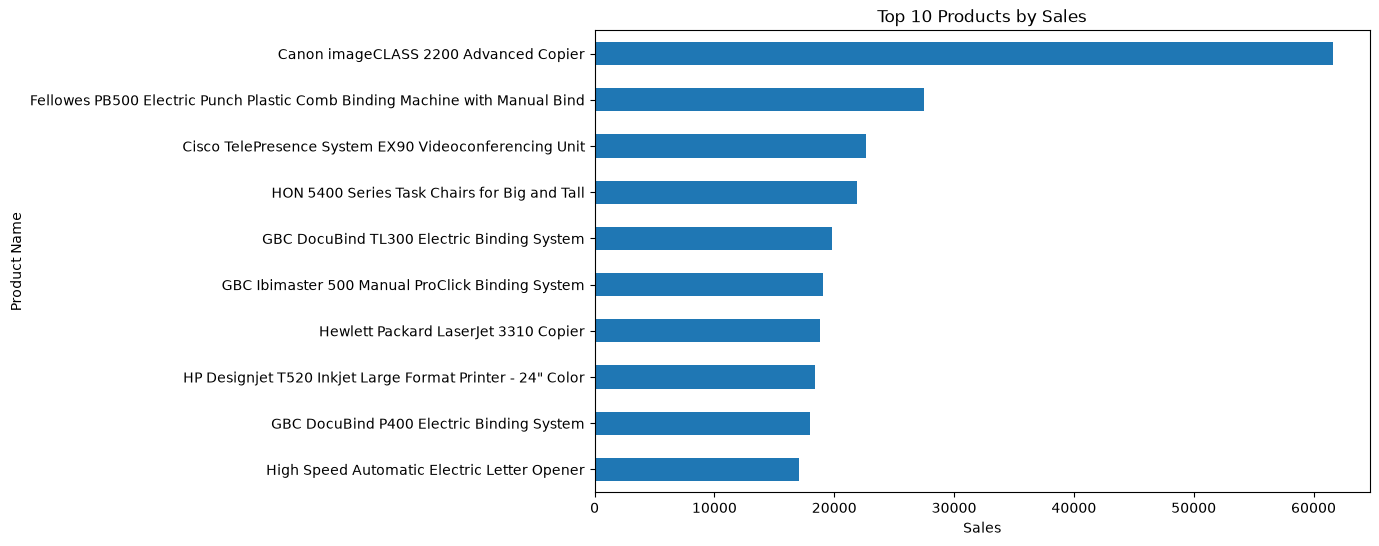

In [46]:
top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))
top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.show()

*Interpretation*: 
- A small number of premium products contribute significantly to overall revenue.
- The **Canon imageCLASS 2200 Advanced Copier** generated the highest single-product sales at **$61,599.82**, followed by the **Fellowes PB500 Electric Punch Binding Machine** (**$27,453.38**) and the **Cisco TelePresence System EX90** (**$22,638.48**).


### 7.5 Correlation & Discount Sensitivity Analysis

**Purpose**: Compute a numerical correlation matrix and generate a scatter plot examining the relationship between Discount and Profit.
**Why**: Evaluates whether promotional discounting drives incremental profitability or erodes profit margins.
**Expected Insights**: Moderate positive correlation between Sales and Profit (+0.48), and a negative correlation between Discount and Profit (-0.22).


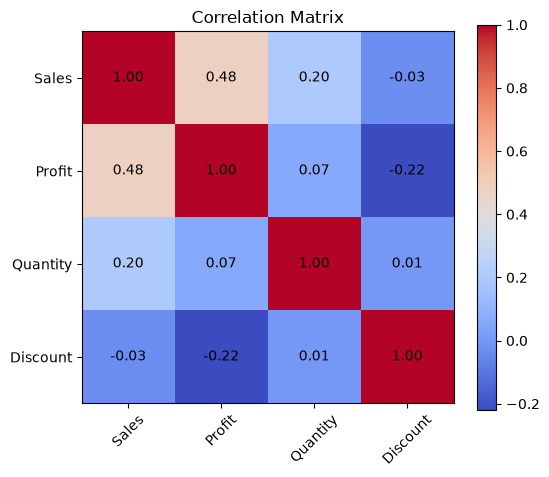

In [51]:
import matplotlib.pyplot as plt

corr = df[["Sales", "Profit", "Quantity", "Discount"]].corr()

plt.figure(figsize=(6,5))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

# Add correlation values inside the heatmap
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="black"
        )

plt.title("Correlation Matrix")
plt.show()

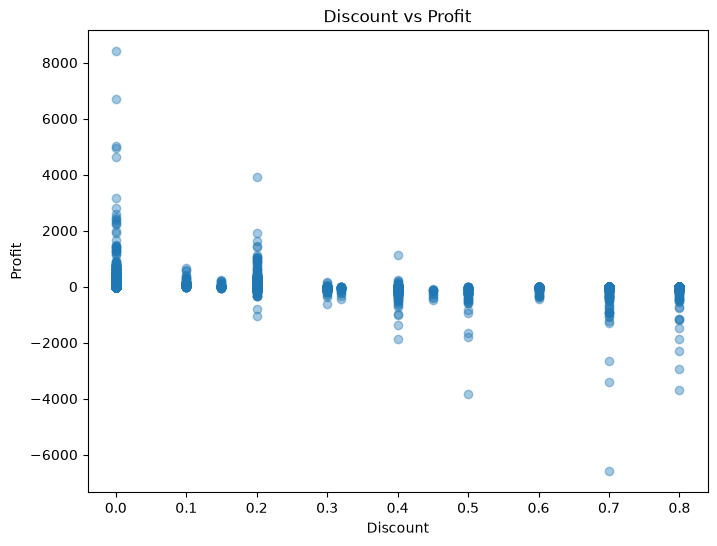

In [52]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Discount"],
    df["Profit"],
    alpha=0.4
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

*Interpretation*:
- **Correlation Matrix**: Sales and Profit exhibit a moderate positive correlation (**+0.48**). In contrast, Discount and Profit display a negative correlation (**-0.22**).
- **Discount Impact**: Higher discounts are strongly associated with lower profitability. Small discounts (0%–15%) generally maintain positive margins, whereas discounts of 20% or higher lead to severe profit erosion and frequent financial losses (down to -$6,599.98).
- **Note on Correlation**: Correlation measures statistical association between variables and does not imply direct causation.


### 7.6 Customer Segment Analysis: Sales & Profit

**Purpose**: Compare Sales and Profit performance across Customer Segments: Consumer, Corporate, and Home Office.
**Why**: Identifies key customer groups contributing most to top-line revenue and bottom-line profit.
**Expected Insights**: Consumer segment dominates sales and profit volume, followed by Corporate and Home Office.


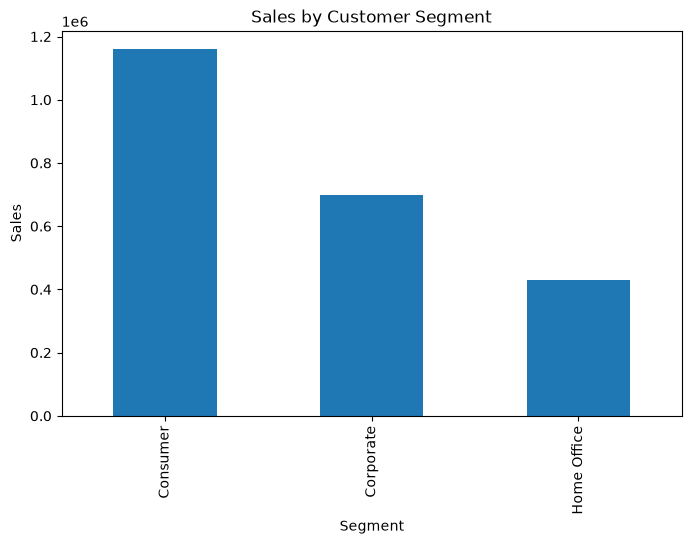

In [53]:
segment_sales = (
    df.groupby("Segment")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

segment_sales.plot(
    kind="bar",
    figsize=(8,5),
    title="Sales by Customer Segment"
)

plt.ylabel("Sales")
plt.show()

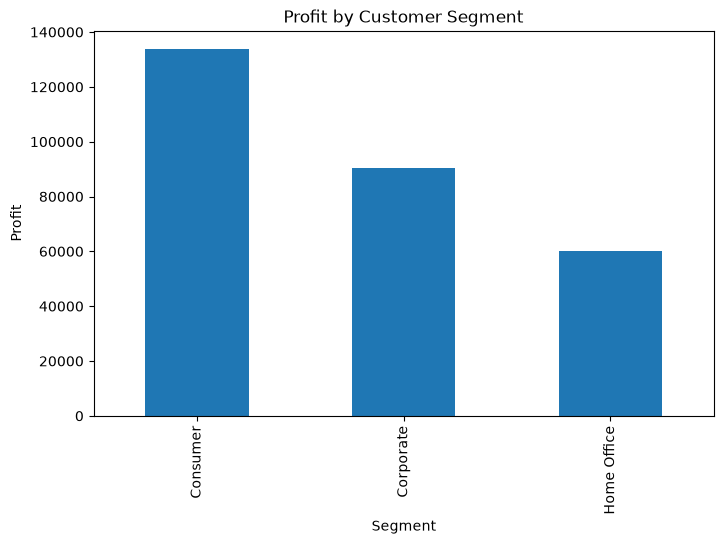

In [54]:
segment_profit = (
    df.groupby("Segment")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

segment_profit.plot(
    kind="bar",
    figsize=(8,5),
    title="Profit by Customer Segment"
)

plt.ylabel("Profit")
plt.show()

*Interpretation*:
- **Consumer Segment**: Contributed the highest total sales (**$1,160,049.07**, ~50.7%) and profit (**$133,744.09**, ~47.1%).
- **Corporate Segment**: Ranked second with **$699,864.07** in sales and **$90,445.91** in profit (12.92% margin).
- **Home Office Segment**: Generated **$428,358.35** in sales and **$59,962.04** in profit, achieving the highest profit margin among all segments at **14.0%**.


## 8. Key Business Insights

Based on the quantitative data analysis and visualizations, the following core insights were identified:

1. **Technology Category Drives High Profitability**: 
   Technology generated the highest total sales (**$834,554.27**) and net profit (**$145,007.66**), delivering a strong 17.38% profit margin. Key drivers include copiers, phones, and accessories.

2. **Furniture Category Exhibits Low Profit Margins**: 
   Despite generating significant sales (**$736,879.70**), Furniture produced a disproportionately low profit of **$17,259.35** (a meager 2.34% profit margin). Heavy promotional discounting and high shipping/handling costs on tables and bookcases severely erode margins.

3. **West Region Outperforms All Other Geographic Territories**: 
   The West region led nationwide performance in both sales (**$725,457.82**) and profit (**$108,418.45**), followed by the East region. Conversely, the Central region suffered from squeezed margins (7.92% profit margin) despite solid sales volume ($501,239.89).

4. **Consumer Segment is the Primary Revenue Generator**: 
   The Consumer segment generated **$1,160,049.07** in sales (over 50% of total company revenue) and **$133,744.09** in profit. Notably, the Home Office segment achieved the highest overall profit margin (14.00%).

5. **Strong Upward Temporal Growth with Seasonal Q4 Surges**: 
   Monthly sales demonstrated a consistent upward trajectory from 2018 through 2021. Demand exhibits strong seasonality, consistently peaking in Q4 (November and December) each year due to corporate budget wrap-ups and holiday purchasing.

6. **Aggressive Discounting Destroys Profit Margins**: 
   A negative correlation (**-0.22**) exists between Discount rates and Profit. Discounts exceeding 20% consistently trigger negative net profit, with extreme discounts (40%–80%) accounting for major financial losses up to -$6,599.98 per order line.

7. **Significant Revenue Concentration in Premium Flagship Products**: 
   Top-line revenue is heavily driven by a select group of high-ticket items. The **Canon imageCLASS 2200 Advanced Copier** alone generated **$61,599.82** in revenue, emphasizing the strategic importance of protecting supply chains and inventory for flagship products.


## 9. Conclusion

### Summary of Completed Objectives
1. **Dataset Cleaning & Validation**: 
   - Ingested and audited 9,994 raw transactional records.
   - Converted `Order Date` and `Ship Date` to datetime format.
   - Identified and handled missing location attributes, resulting in a final cleaned dataset of 9,983 valid records.

2. **Key Performance Indicators (KPIs)**:
   - Core financial and operational KPIs were successfully calculated to establish baseline performance metrics.

3. **Exploratory Data Analysis (EDA)**:
   - Conducted multidimensional EDA across product categories, geographic regions, monthly time-series trends, flagship products, customer segments, and discount correlations.

4. **Business Insights Formulated**:
   - Identified key growth drivers (Technology category, West region, Consumer segment) and margin risks (Furniture low profit margin, aggressive discounting >= 20%).

5. **Cleaned Dataset Exported**:
   - Exported the finalized cleaned dataset to `../../data/cleaned/superstore_cleaned.csv`.

The cleaned dataset and analytical findings establish a reliable foundation for subsequent project deliverables, including SQL database queries, Excel analytical models, Power BI interactive dashboards, and the comprehensive EDA report.
